<a href="https://colab.research.google.com/github/bikebhunia/My_multilingualBERT/blob/main/MultiLingual_BERT_Bengali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install -q "transformers>=4.41.0,<6.0.0" torch torchvision accelerate tqdm scikit-learn pandas matplotlib seaborn

In [ ]:
from google.colab import files
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

Saving bengali-hate-speech_train.csv to bengali-hate-speech_train (1).csv


In [ ]:

import os, gc, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline   ← paste this magic in the actual Colab cell

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix,
)
import torch
import torch.nn as nn
from torch.optim import AdamW                          #  torch AdamW, not transformers
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast        #  AMP fp16

from transformers import (
    BertTokenizerFast,                                 #  Rust-backed fast tokeniser
    BertForSequenceClassification,
    get_cosine_schedule_with_warmup,                   #  cosine > linear for T4
)
from tqdm.auto import tqdm

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── T4 kernel auto-tuning ─────────────────────────────────────────
torch.backends.cudnn.benchmark = True                  #  auto-selects fastest kernels

# ── Device ────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_CUDA = DEVICE.type == "cuda"
print(f"\n{'═'*60}")
print(f"  Device  : {DEVICE}")
if IS_CUDA:
    props = torch.cuda.get_device_properties(0)
    total_vram = props.total_memory / 1e9
    print(f"  GPU     : {props.name}")
    print(f"  VRAM    : {total_vram:.1f} GB")
    print(f"  CUDA    : {torch.version.cuda}")
    if "T4" not in props.name:
        print("    Non-T4 GPU detected — settings still apply but VRAM may differ")
print(f"{'═'*60}\n")
# ── Model ─────────────────────────────────────────────────────────
MODEL_NAME = "bert-base-multilingual-cased"
# ── Hyper-parameters (tuned for T4 16 GB) ────────────────────────
MAX_LEN          = 128   # hard cap; dynamic padding will use less in practice
BATCH_SIZE       = 32    # ✦ safe fp16 batch for T4 (16 GB) — was 16 in fp32
GRAD_ACCUM_STEPS = 4     # ✦ effective batch = 32 × 4 = 128
EPOCHS           = 5
LR               = 3e-5  # slightly higher LR suits cosine schedule
WARMUP_RATIO     = 0.1   # 10 % of total steps for warm-up
THRESHOLD        = 0.5   # sigmoid binarisation threshold
PATIENCE         = 2     # ✦ early stopping: stop after 2 non-improving epochs

# ── Labels ────────────────────────────────────────────────────────
LABEL_COLS = ["defamation", "hate", "non-hate", "violence", "vulgar"]
NUM_LABELS = len(LABEL_COLS)

# ── Paths ─────────────────────────────────────────────────────────
CSV_PATH   = "/content/bengali-hate-speech_train (1).csv"   # ← change if needed
OUTPUT_DIR = "/content/outputs"
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CKPT_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"  ✅  Output dir : {OUTPUT_DIR}")
print(f"  ✅  Checkpoint : {CKPT_DIR}")


════════════════════════════════════════════════════════════
  Device  : cuda
  GPU     : Tesla T4
  VRAM    : 15.6 GB
  CUDA    : 12.8
════════════════════════════════════════════════════════════

  ✅  Output dir : /content/outputs
  ✅  Checkpoint : /content/outputs/checkpoints


In [ ]:
def vram_usage() -> str:
    """Return a one-line VRAM usage string (only on CUDA)."""
    if not IS_CUDA:
        return "CPU"
    alloc  = torch.cuda.memory_allocated(0)  / 1e9
    reserv = torch.cuda.memory_reserved(0)   / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    return f"{alloc:.1f} GB alloc / {reserv:.1f} GB reserved / {total:.1f} GB total"

# ── 4a. Load & validate data ──────────────────────────────────────

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(f"\n{'═'*60}")
    print(f"  Rows loaded  : {len(df):,}")
    print(f"  Columns      : {list(df.columns)}")

    # Auto-detect text column
    candidates = ["text", "sentence", "comment", "content", "tweet",
                  "data", "Text", "Sentence", "Comment"]
    text_col = next((c for c in candidates if c in df.columns), None)
    if text_col is None:
        text_col = [c for c in df.columns if c not in LABEL_COLS][0]
    print(f"  Text column  : '{text_col}'")

    # Validate label columns
    missing = [c for c in LABEL_COLS if c not in df.columns]
    if missing:
        raise ValueError(
            f"CSV is missing label columns: {missing}\n"
            f"Found: {list(df.columns)}"
        )

    df = df[[text_col] + LABEL_COLS].dropna()
    df = df.rename(columns={text_col: "text"})
    for col in LABEL_COLS:
        df[col] = df[col].astype(int)

    print(f"\n  Label distribution (after dropna):")
    for col in LABEL_COLS:
        n   = df[col].sum()
        pct = 100 * n / len(df)
        bar = "█" * int(pct / 2)
        print(f"    {col:<12} {bar:<26} {n:>6,}  ({pct:.1f} %)")
    print(f"{'═'*60}\n")
    return df
# ── 4b. Pre-tokenise entire dataset upfront ───────────────────────
#
#   WHY: In the old code tokenisation happens inside __getitem__,
#   meaning every epoch re-tokenises the whole dataset on CPU.
#   Pre-tokenising once cuts per-epoch overhead to near zero.

def pretokenise(texts: pd.Series, tokenizer) -> dict:
    """
    Tokenise all texts in one fast batched call.
    Returns a dict of lists (no padding yet — dynamic padding happens
    inside the collate_fn per batch for maximum efficiency).
    """
    print(f"  Pre-tokenising {len(texts):,} texts …", end=" ", flush=True)
    t0 = time.time()
    encodings = tokenizer(
        texts.tolist(),
        max_length     = MAX_LEN,
        truncation     = True,
        padding        = False,    # ✦ no padding here — done dynamically per batch
        return_tensors = None,     # returns plain Python lists
    )
    print(f"done in {time.time()-t0:.1f}s")
    return encodings               # keys: input_ids, attention_mask, token_type_ids

# ── 4c. Dataset (uses pre-tokenised cache) ────────────────────────

class BengaliHateSpeechDataset(Dataset):
    """
    Stores pre-tokenised token ID lists.
    No tokenisation happens in __getitem__ — just list→tensor conversion.
    """
    def __init__(self, encodings: dict, labels: pd.DataFrame):
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.token_type_ids = encodings["token_type_ids"]
        self.labels         = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids"      : torch.tensor(self.input_ids[idx],      dtype=torch.long),
            "attention_mask" : torch.tensor(self.attention_mask[idx],  dtype=torch.long),
            "token_type_ids" : torch.tensor(self.token_type_ids[idx],  dtype=torch.long),
            "labels"         : torch.tensor(
                self.labels.iloc[idx].values, dtype=torch.float
            ),
        }
# ── 4d. Dynamic-padding collate function ─────────────────────────
#
#   WHY: Padding every sample to MAX_LEN=128 wastes ~30–40 % of
#   BERT's attention FLOPs on PAD tokens.  Dynamic padding pads
#   each mini-batch only to its own longest sequence, cutting
#   compute significantly for short Bengali texts.

def dynamic_pad_collate(batch: list, pad_id: int = 0) -> dict:
    """Pad each field to the longest sequence in the current batch."""
    max_len = max(len(item["input_ids"]) for item in batch)

    input_ids_b      = []
    attention_mask_b = []
    token_type_ids_b = []
    labels_b         = []

    for item in batch:
        seq_len = len(item["input_ids"])
        pad_len = max_len - seq_len

        input_ids_b.append(
            torch.cat([item["input_ids"],
                       torch.full((pad_len,), pad_id, dtype=torch.long)])
        )
        attention_mask_b.append(
            torch.cat([item["attention_mask"],
                       torch.zeros(pad_len, dtype=torch.long)])
        )
        token_type_ids_b.append(
            torch.cat([item["token_type_ids"],
                       torch.zeros(pad_len, dtype=torch.long)])
        )
        labels_b.append(item["labels"])

    return {
        "input_ids"      : torch.stack(input_ids_b),
        "attention_mask" : torch.stack(attention_mask_b),
        "token_type_ids" : torch.stack(token_type_ids_b),
        "labels"         : torch.stack(labels_b),
    }
# ── 4e. Training epoch (AMP + gradient accumulation) ─────────────

def train_epoch(model, loader, optimizer, scheduler, scaler, epoch: int) -> float:
    """
    One training pass.
    ✦ autocast()   — runs forward + loss in fp16 on Tensor Cores
    ✦ GradScaler   — prevents fp16 underflow in gradients
    ✦ Grad accum   — accumulates GRAD_ACCUM_STEPS micro-batches before
                     updating weights → effective batch = 128
    """
    model.train()
    total_loss    = 0.0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(loader), total=len(loader),
                desc=f"  Epoch {epoch} [Train]", leave=False, dynamic_ncols=True)

    for step, batch in pbar:
        # ✦ non_blocking=True: CPU→GPU transfer overlaps with computation
        input_ids      = batch["input_ids"].to(DEVICE,      non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE,  non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(DEVICE,  non_blocking=True)
        labels         = batch["labels"].to(DEVICE,          non_blocking=True)

        # ✦ AMP: forward pass in fp16
        with autocast():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids,
                labels         = labels,
            )
            # Scale loss for gradient accumulation
            loss = outputs.loss / GRAD_ACCUM_STEPS

        # ✦ scaler.scale preserves fp16 gradients
        scaler.scale(loss).backward()

        # Update weights only every GRAD_ACCUM_STEPS steps
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            # Unscale before clipping so clip threshold is in fp32 units
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += outputs.loss.item()          # log raw (un-divided) loss
        pbar.set_postfix({
            "loss" : f"{outputs.loss.item():.4f}",
            "VRAM" : vram_usage().split("/")[0].strip(),
        })
    return total_loss / len(loader)

# ── 4f. Evaluation (AMP inference) ───────────────────────────────

def evaluate(model, loader, desc: str = "Eval") -> tuple:
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0.0

    pbar = tqdm(loader, desc=f"  {desc}", leave=False, dynamic_ncols=True)
    with torch.no_grad():
        for batch in pbar:
            input_ids      = batch["input_ids"].to(DEVICE,      non_blocking=True)
            attention_mask = batch["attention_mask"].to(DEVICE,  non_blocking=True)
            token_type_ids = batch["token_type_ids"].to(DEVICE,  non_blocking=True)
            labels         = batch["labels"].to(DEVICE,          non_blocking=True)

            # ✦ AMP also applies during inference — same speed benefit
            with autocast():
                outputs = model(
                    input_ids      = input_ids,
                    attention_mask = attention_mask,
                    token_type_ids = token_type_ids,
                    labels         = labels,
                )

            total_loss += outputs.loss.item()
            probs = torch.sigmoid(outputs.logits)
            preds = (probs >= THRESHOLD).int()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().int().numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    return all_preds, all_labels, total_loss / len(loader)
# ── 4g. Metrics ───────────────────────────────────────────────────

def print_metrics(y_true: np.ndarray, y_pred: np.ndarray, split: str = "Test"):
    print(f"\n{'═'*60}")
    print(f"  {split} Results  (threshold={THRESHOLD})")
    print(f"{'═'*60}")

    exact_acc = accuracy_score(y_true, y_pred)
    correct   = int(exact_acc * len(y_true))
    print(f"\n  Exact-match Accuracy : {exact_acc:.4f}  ({correct:,}/{len(y_true):,})")

    print(f"\n  Per-label Accuracy:")
    for i, col in enumerate(LABEL_COLS):
        print(f"    {col:<12}  {accuracy_score(y_true[:,i], y_pred[:,i]):.4f}")

    macro_f1  = f1_score(y_true, y_pred, average="macro",   zero_division=0)
    micro_f1  = f1_score(y_true, y_pred, average="micro",   zero_division=0)
    sample_f1 = f1_score(y_true, y_pred, average="samples", zero_division=0)
    print(f"\n  Macro  F1 : {macro_f1:.4f}")
    print(f"  Micro  F1 : {micro_f1:.4f}")
    print(f"  Sample F1 : {sample_f1:.4f}")

    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=LABEL_COLS, zero_division=0))

# ── 4h. Plots ─────────────────────────────────────────────────────

def plot_label_distribution(df: pd.DataFrame, save_dir: str = OUTPUT_DIR):
    counts  = df[LABEL_COLS].sum().sort_values(ascending=False)
    colours = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0"]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(counts.index, counts.values, color=colours,
                  edgecolor="white", width=0.55, zorder=3)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+30,
                f"{val:,}", ha="center", fontsize=11, fontweight="bold")
    ax.set_title("Label Distribution — Bengali Hate Speech",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Count"); ax.set_xlabel("Label")
    plt.tight_layout()
    p = os.path.join(save_dir, "label_distribution.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  ✅  Saved → {p}")
def plot_confusion_matrices(y_true: np.ndarray, y_pred: np.ndarray,
                             save_dir: str = OUTPUT_DIR):
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, NUM_LABELS, figsize=(22, 4))
    fig.suptitle("Confusion Matrices — Bengali Hate Speech (mBERT)",
                 fontsize=14, fontweight="bold", y=1.02)
    for ax, matrix, label in zip(axes, mcm, LABEL_COLS):
        grp  = ["TN","FP","FN","TP"]
        cnts = [f"{v:,}" for v in matrix.flatten()]
        pcts = [f"\n({v:.1%})" for v in matrix.flatten()/matrix.sum()]
        ann  = np.array([f"{g}\n{c}{p}" for g,c,p in
                         zip(grp,cnts,pcts)]).reshape(2,2)
        sns.heatmap(matrix, annot=ann, fmt="", cmap="Blues",
                    xticklabels=["Pred 0","Pred 1"],
                    yticklabels=["True 0","True 1"],
                    ax=ax, linewidths=0.5, linecolor="white")
        ax.set_title(label, fontweight="bold", fontsize=11)
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Actual",    fontsize=9)
    plt.tight_layout()
    p = os.path.join(save_dir, "confusion_matrices.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  ✅  Saved → {p}")

def plot_f1_per_label(y_true: np.ndarray, y_pred: np.ndarray,
                      save_dir: str = OUTPUT_DIR):
    f1s     = f1_score(y_true, y_pred, average=None, zero_division=0)
    colours = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0"]
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(LABEL_COLS, f1s, color=colours, edgecolor="white",
                  width=0.55, zorder=3)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    for bar, s in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                f"{s:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_title("F1 Score per Label — Bengali Hate Speech (mBERT)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("F1 Score"); ax.set_xlabel("Label")
    plt.tight_layout()
    p = os.path.join(save_dir, "f1_per_label.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  ✅  Saved → {p}")

def plot_training_curve(train_losses: list, val_losses: list,
                         save_dir: str = OUTPUT_DIR):
    epochs = range(1, len(train_losses)+1)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, train_losses, "o-", label="Train Loss",
            color="#2196F3", linewidth=2, markersize=7)
    ax.plot(epochs, val_losses,   "s-", label="Val Loss",
            color="#F44336", linewidth=2, markersize=7)
    ax.fill_between(epochs, train_losses, val_losses, alpha=0.08, color="grey")
    ax.set_title("Training & Validation Loss (BCE + AMP)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.set_xticks(list(epochs)); ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    p = os.path.join(save_dir, "training_curve.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  ✅  Saved → {p}")
# ── 4i. Checkpoint helpers ────────────────────────────────────────

def save_checkpoint(model, tokenizer, optimizer, scaler,
                    epoch: int, val_loss: float, ckpt_dir: str = CKPT_DIR):
    """Save everything needed to resume if Colab disconnects."""
    path = os.path.join(ckpt_dir, f"epoch_{epoch:02d}_valloss_{val_loss:.4f}")
    os.makedirs(path, exist_ok=True)
    model.save_pretrained(path)
    tokenizer.save_pretrained(path)
    torch.save({
        "epoch"     : epoch,
        "val_loss"  : val_loss,
        "opt_state" : optimizer.state_dict(),
        "scaler"    : scaler.state_dict(),
    }, os.path.join(path, "trainer_state.pt"))
    print(f"  💾  Checkpoint saved → {path}")
    return path

def load_best_checkpoint(ckpt_dir: str = CKPT_DIR):
    """Load the checkpoint with the lowest validation loss."""
    ckpts = [d for d in os.listdir(ckpt_dir) if d.startswith("epoch_")]
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")
    # Parse val_loss from directory name
    best = min(ckpts, key=lambda d: float(d.split("valloss_")[-1]))
    path = os.path.join(ckpt_dir, best)
    print(f"  🏆  Best checkpoint : {path}")
    return path



════════════════════════════════════════════════════════════
  Rows loaded  : 11,251
  Columns      : ['text', 'defamation', 'hate', 'non-hate', 'violence', 'vulgar']
  Text column  : 'text'

  Label distribution (after dropna):
    defamation   █████████████               2,934  (26.1 %)
    hate         █████                       1,320  (11.7 %)
    non-hate     ███████████████████████     5,274  (46.9 %)
    violence     ████████                    1,856  (16.5 %)
    vulgar       ███████                     1,752  (15.6 %)
════════════════════════════════════════════════════════════



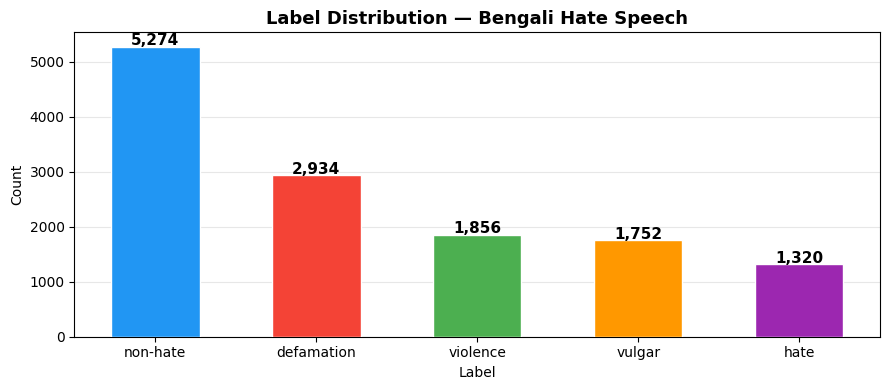

  ✅  Saved → /content/outputs/label_distribution.png
  Loading tokeniser → bert-base-multilingual-cased …


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Pre-tokenising 11,251 texts … done in 1.1s

  Train : 9,000  |  Test : 2,251

  Loading model → bert-base-multilingual-cased …


...

  💾  Checkpoint saved → /content/outputs/checkpoints/epoch_05_valloss_0.2503
  ⚠  No improvement (1/2)

  Loading best checkpoint for final evaluation …


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Running final evaluation on test set …



  Final Eval:   0%|          | 0/36 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
  Test Results  (threshold=0.5)
════════════════════════════════════════════════════════════

  Exact-match Accuracy : 0.6797  (1,530/2,251)

  Per-label Accuracy:
    defamation    0.8201
    hate          0.9156
    non-hate      0.9169
    violence      0.9000
    vulgar        0.9498

  Macro  F1 : 0.7331
  Micro  F1 : 0.7792
  Sample F1 : 0.7495

  Classification Report:

              precision    recall  f1-score   support

  defamation       0.64      0.66      0.65       572
        hate       0.67      0.58      0.62       267
    non-hate       0.92      0.91      0.91      1064
    violence       0.72      0.61      0.66       359
      vulgar       0.89      0.77      0.82       341

   micro avg       0.80      0.76      0.78      2603
   macro avg       0.77      0.70      0.73      2603
weighted avg       0.80      0.76      0.78      2603
 samples avg       0.75      0.76      0.75      2603



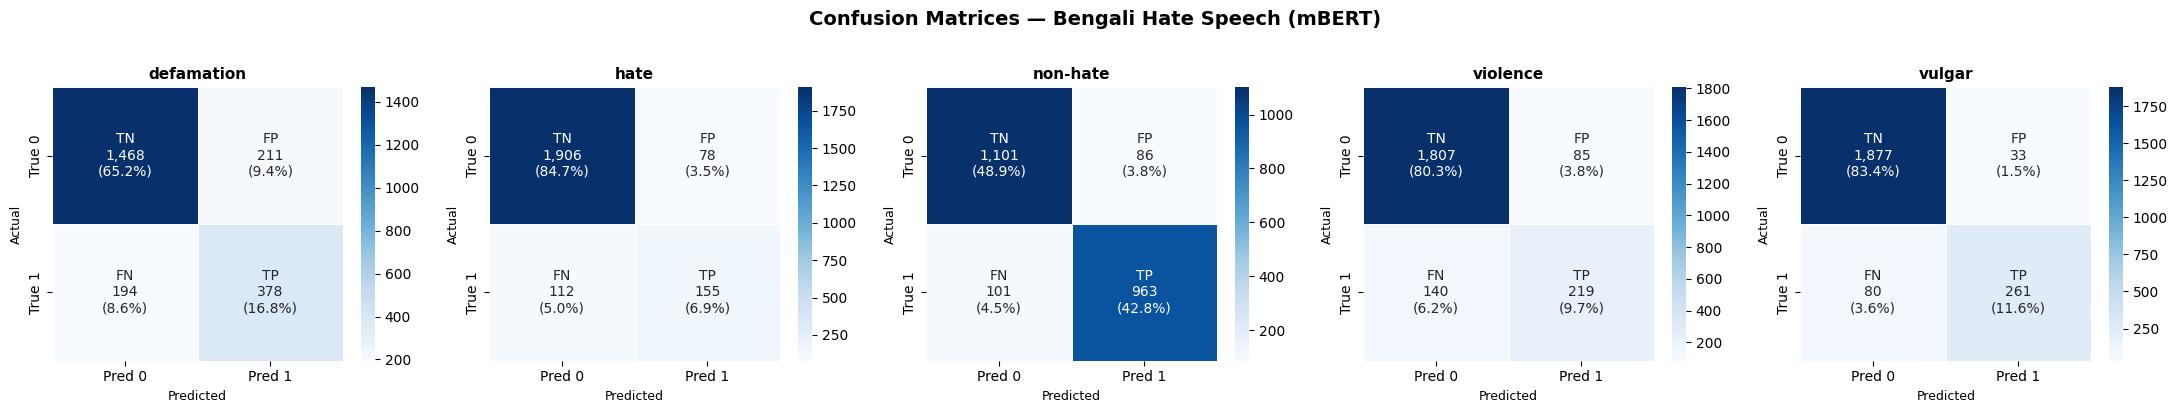

  ✅  Saved → /content/outputs/confusion_matrices.png


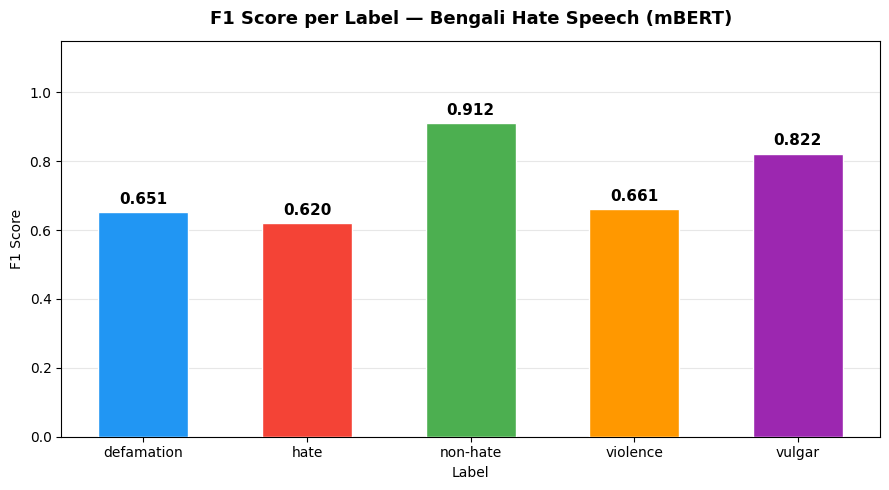

  ✅  Saved → /content/outputs/f1_per_label.png


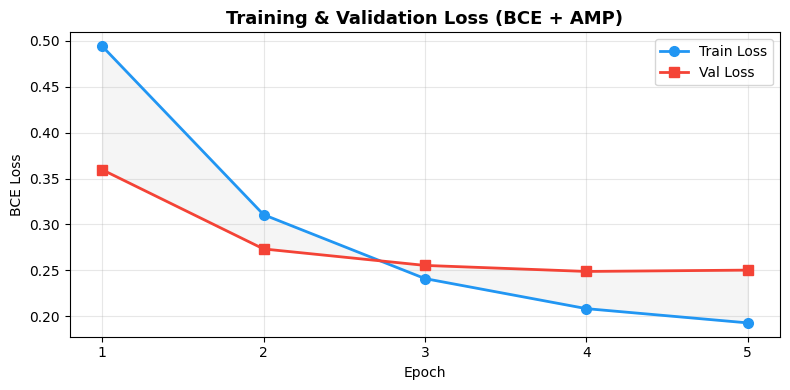

  ✅  Saved → /content/outputs/training_curve.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  ✅  Final model saved → /content/outputs/mbert_bengali_hate_final
  ⏱  Total wall-clock time : 7.5 min

════════════════════════════════════════════════════════════
  Done. All outputs in : /content/outputs
════════════════════════════════════════════════════════════



In [ ]:
def run_training(
    csv_path   : str = CSV_PATH,
    output_dir : str = OUTPUT_DIR,
):
    """
    Full T4-optimised pipeline:
      load → pre-tokenise → split → DataLoaders →
      model → AMP train (with early stopping + checkpoints) →
      evaluate → plots → save
    """
    t_start = time.time()

    # ── 1. Load data ──────────────────────────────────────────────
    df = load_data(csv_path)
    plot_label_distribution(df, save_dir=output_dir)

    # ── 2. Tokeniser (Fast = Rust-backed, ~10× quicker) ───────────
    print(f"  Loading tokeniser → {MODEL_NAME} …")
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

    # ── 3. Pre-tokenise once (not per epoch, not per sample) ──────
    all_encodings = pretokenise(df["text"], tokenizer)
    labels_df     = df[LABEL_COLS]

    # ── 4. Train / test split ─────────────────────────────────────
    indices = list(range(len(df)))
    train_idx, test_idx = train_test_split(
        indices, test_size=0.20, random_state=SEED, shuffle=True
    )
    def subset_encodings(enc, idx):
        return {k: [v[i] for i in idx] for k, v in enc.items()}

    train_enc = subset_encodings(all_encodings, train_idx)
    test_enc  = subset_encodings(all_encodings, test_idx)
    y_train   = labels_df.iloc[train_idx]
    y_test    = labels_df.iloc[test_idx]

    print(f"\n  Train : {len(train_idx):,}  |  Test : {len(test_idx):,}\n")

    # ── 5. Datasets & DataLoaders ─────────────────────────────────
    train_ds = BengaliHateSpeechDataset(train_enc, y_train)
    test_ds  = BengaliHateSpeechDataset(test_enc,  y_test)

    # Capture pad_token_id for the collate_fn closure
    pad_id = tokenizer.pad_token_id

    def collate_fn(batch):
        return dynamic_pad_collate(batch, pad_id=pad_id)

    # ✦ persistent_workers keeps worker processes alive between epochs
    # ✦ pin_memory pre-pins CPU tensors for fast DMA transfer to GPU
    # ✦ prefetch_factor=2 pre-loads next 2 batches while GPU is busy
    _workers = 2 if IS_CUDA else 0
    _pin     = IS_CUDA

    train_loader = DataLoader(
        train_ds,
        batch_size       = BATCH_SIZE,
        shuffle          = True,
        num_workers      = _workers,
        pin_memory       = _pin,
        persistent_workers = (_workers > 0),
        prefetch_factor  = 2 if _workers > 0 else None,
        collate_fn       = collate_fn,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size       = BATCH_SIZE * 2,   # ✦ 2× batch for inference (no grad)
        shuffle          = False,
        num_workers      = _workers,
        pin_memory       = _pin,
        persistent_workers = (_workers > 0),
        prefetch_factor  = 2 if _workers > 0 else None,
        collate_fn       = collate_fn,
    )

    # ── 6. Model ──────────────────────────────────────────────────
    print(f"  Loading model → {MODEL_NAME} …")
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels   = NUM_LABELS,
        problem_type = "multi_label_classification",   # BCEWithLogitsLoss
    )
    model.to(DEVICE)
    print(f"  ✅  Model on {DEVICE}  |  VRAM: {vram_usage()}\n")

    # ── 7. Optimiser, Scheduler, Scaler ───────────────────────────
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

    # Effective steps account for gradient accumulation
    effective_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
    warmup_steps    = int(WARMUP_RATIO * effective_steps)

    # ✦ Cosine schedule gives a smooth LR decay — better than linear for T4
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = effective_steps,
    )

    # ✦ GradScaler manages loss scaling to avoid fp16 underflow
    scaler = GradScaler(enabled=IS_CUDA)

    # ── 8. Training loop with early stopping ─────────────────────
    print(f"  {'─'*56}")
    print(f"  Training  |  Epochs={EPOCHS}  Batch={BATCH_SIZE}  "
          f"EffBatch={BATCH_SIZE*GRAD_ACCUM_STEPS}  LR={LR}")
    print(f"  AMP={IS_CUDA}  Workers={_workers}  EarlyStop(patience={PATIENCE})")
    print(f"  {'─'*56}\n")

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    no_improve    = 0
    best_ckpt     = None

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        tr_loss = train_epoch(
            model, train_loader, optimizer, scheduler, scaler, epoch
        )
        _, _, va_loss = evaluate(model, test_loader, desc=f"Epoch {epoch} [Val]")

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        elapsed = time.time() - epoch_start

        print(f"  Epoch {epoch}/{EPOCHS}  |  "
              f"Train Loss : {tr_loss:.4f}  |  Val Loss : {va_loss:.4f}  |  "
              f"⏱ {elapsed:.0f}s  |  VRAM: {vram_usage().split('/')[0].strip()}")

        # ── Checkpoint every epoch (Colab can disconnect anytime) ─
        ckpt_path = save_checkpoint(
            model, tokenizer, optimizer, scaler, epoch, va_loss
        )

        # ── Early stopping ────────────────────────────────────────
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_ckpt     = ckpt_path
            no_improve    = 0
            print(f"  ✅  New best val loss : {best_val_loss:.4f}")
        else:
            no_improve += 1
            print(f"  ⚠  No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print(f"\n  🛑  Early stopping triggered after epoch {epoch}.")
                break

        # Free CUDA cache between epochs
        if IS_CUDA:
            torch.cuda.empty_cache()
            gc.collect()
# ── 9. Load best checkpoint for final evaluation ──────────────
    print(f"\n  Loading best checkpoint for final evaluation …")
    best_path = best_ckpt if best_ckpt else load_best_checkpoint()
    model_best = BertForSequenceClassification.from_pretrained(best_path)
    model_best.to(DEVICE)

    # Re-build test_loader with best model  (same test_ds, just re-evaluate)
    print("  Running final evaluation on test set …\n")
    y_pred, y_true, _ = evaluate(model_best, test_loader, desc="Final Eval")

    print_metrics(y_true, y_pred, split="Test")
    plot_confusion_matrices(y_true, y_pred, save_dir=output_dir)
    plot_f1_per_label(y_true, y_pred,       save_dir=output_dir)
    plot_training_curve(train_losses, val_losses, save_dir=output_dir)

    # ── 10. Save final model ──────────────────────────────────────
    final_path = os.path.join(output_dir, "mbert_bengali_hate_final")
    model_best.save_pretrained(final_path)
    tokenizer.save_pretrained(final_path)

    total_time = time.time() - t_start
    print(f"\n  ✅  Final model saved → {final_path}")
    print(f"  ⏱  Total wall-clock time : {total_time/60:.1f} min")
    print(f"\n{'═'*60}")
    print(f"  Done. All outputs in : {output_dir}")
    print(f"{'═'*60}\n")

    return model_best, tokenizer
# ── Run ───────────────────────────────────────────────────────────
model, tokenizer = run_training()